In [179]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import finufft

In [ ]:
# ---== Global Variables ==--- #
num_threads = 2

In [181]:
# ---== wave vector generation ==--- #

# We always assume the domain is [0, 1]^2

def generate_k_vectors(num_per_dim = 52, L = 1.0):
    """
    Generate wavevectors
    on a uniform 2D grid using fftfreq
    x:=num_per_dim ~ such that (x*x/2)/(4*N) = 4/10 <=> x = 4 * sqrt(2N/10)
    """

    min_threshhold = np.pi

    kx = np.fft.fftfreq(num_per_dim, d=L/num_per_dim) * 2 * np.pi
    ky = np.fft.fftfreq(num_per_dim, d=L/num_per_dim) * 2 * np.pi
    kx, ky = np.meshgrid(kx[kx >= 0.0], ky, indexing='ij')
    k_flat = np.stack((kx.ravel(), ky.ravel()), axis=0)
    
    # Apply cutoff
    max_k = np.max(np.abs(k_flat), axis=0)
    mask = (max_k > min_threshhold)
    return k_flat[:, mask]  # shape: (2, nk)


In [182]:
# ---== inital point pattern generation ==--- #

# Important: the domain is always [0, 1]^2

def random_point_pattern(N):
    return np.random.uniform(0, 1, size=(N, 2)) # shape : (rN, 2)

# ------
# the following methods generate approximately N points and exactly N points if N = k^2, for some k

def uniform_point_pattern(N):
    rN = round(np.sqrt(N))
    space = np.linspace(0.01, .99, rN)
    return np.array(np.meshgrid(space, space)).reshape(2, -1).T # shape : (rN, 2)

def perturbed_point_pattern(N, eps=0.01):
    uniform = uniform_point_pattern(N)
    rN = uniform.shape[0]
    pert_x = eps*np.random.uniform(-1, 1, size=(rN,))
    pert_y = eps*np.random.uniform(-1, 1, size=(rN,))
    uniform[:, 0] += pert_x
    uniform[:, 1] += pert_y
    return uniform  # shape : (rN, 2)

In [183]:
# weight function for different k vectors to ensure constraints equally 
# strong on all spherical shells for radially symmetric structure factors
def weight(k):
    k_magnitude = np.linalg.norm(k, axis=0)  # (M,)
    return 1./k_magnitude

def compute_rho(k, r):
    N = r.shape[0]
    rx = np.ascontiguousarray(r[:, 0])
    ry = np.ascontiguousarray(r[:, 1])
    c = np.ones(N, dtype=np.complex128)
    return finufft.nufft2d3(rx, ry, c, k[0, :], k[1, :], eps=1e-12, isign=+1, nthreads=num_threads) # (M,)

# for optimization purposes
def compute_S_rho(rho, N):
    return np.abs(rho)**2 / N

def compute_S(k, r):
    N = r.shape[0]
    return compute_S_rho(compute_rho(k, r), N)

def compute_bump(x, K_cutoff):
    A = 0.5                   # Height of the hill
    x0 = 0.95                 # Center of the hill before cutoff
    sigma = 0.05              # Width of the hill
    bump = 1 + A * np.exp(-((x - x0)**2) / (2 * sigma**2))
    #bump = np.where(x < K_cutoff, bump, 0.0)
    return bump

def compute_S0(k, D, H, alpha, K_cutoff):
    k_magnitude = np.linalg.norm(k, axis=0)  # (M,)
    S0 = np.where(k_magnitude < K_cutoff, D * (1 - H) * (k_magnitude**alpha) + H, 1.0)
    return S0 #* compute_bump(k_magnitude/K_cutoff, K_cutoff)

def objective_function(x, k, S0_k):
    N = x.shape[0] // 2
    r = x.reshape(N, 2)
    r = np.mod(r, 1.0)
    S_kr = compute_S(k, r)
    return np.sum(weight(k) * (S_kr - S0_k)**2)

def gradient_function(x, k, S0_k):
    N = x.shape[0] // 2
    r = x.reshape(N, 2)
    r = np.mod(r, 1.0)
    grad = np.zeros_like(r) # (N, 2)
    rho = compute_rho(k, r) # (M,)
    S_kr = compute_S_rho(rho, N) # (M,)
    factor = -4.j/N * weight(k) * ((S_kr - S0_k) * rho)
    C_hat_x = k[0, :] * factor # (M, )
    C_hat_y = k[1, :] * factor # (M, )
    rx = np.ascontiguousarray(r[:, 0])
    ry = np.ascontiguousarray(r[:, 1])
    grad[:, 0] = np.real(finufft.nufft2d3(k[0, :], k[1, :], C_hat_x, rx, ry, isign=-1, nthreads=num_threads))
    grad[:, 1] = np.real(finufft.nufft2d3(k[0, :], k[1, :], C_hat_y, rx, ry, isign=-1, nthreads=num_threads))
    return grad.flatten()

In [184]:
# ---== Visualization ==--- #

def plot_wave_vectors(k):
    plt.figure(figsize=(6, 6))
    plt.scatter(k[0, :], k[1, :], marker="x", color="green")
    plt.xlabel("$k_x$")
    plt.ylabel("$k_y$")
    plt.title("Wave vectors")
    plt.show()

def plot_particles(r, title):
    plt.figure(figsize=(6, 6))
    r = np.mod(r, 1.0) 
    plt.scatter(r[:, 0], r[:, 1], c="blue", s=20)
    plt.title(title)
    plt.gca().set_aspect('equal')
    plt.show()

def plot_structure_factor(r, k, K_cutoff, S0_k, title):
    S_kr = compute_S(k, r)
    print(S_kr.shape)
    k_magnitude = np.linalg.norm(k, axis=0)
    plt.figure(figsize=(8, 5))
    plt.scatter(k_magnitude/K_cutoff, S_kr, color="red", label="Computed S(k)")
    plt.scatter(k_magnitude/K_cutoff, S0_k, color="green", label="Computed S_0(k)", marker="x")
    plt.xlabel("|k|/K")
    plt.ylabel("S(k)")
    plt.title(title)
    plt.legend()
    plt.show()

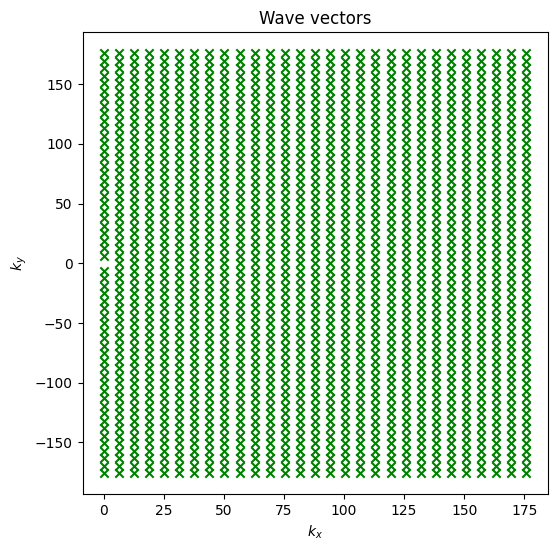

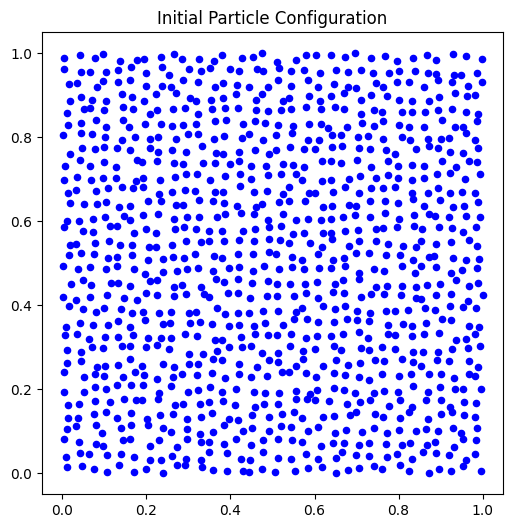

(1652,)


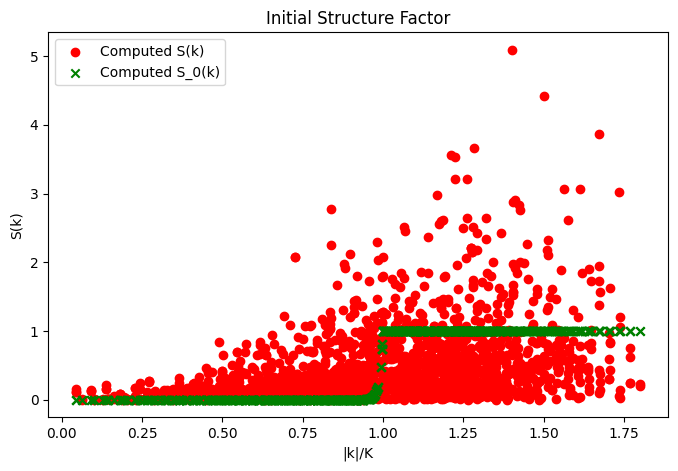

Value before optimizing:  4.319484777017647
         Current function value: 2.226806
         Iterations: 1
         Function evaluations: 4
         Gradient evaluations: 4
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: 2.2268056921499744
        x: [ 1.318e-02  1.806e-02 ...  1.001e+00  9.845e-01]
      nit: 1
      jac: [ 1.844e-01 -4.837e-01 ...  4.695e-02  2.910e-02]
 hess_inv: [[ 9.993e-01 -5.914e-04 ... -5.011e-04  3.746e-04]
            [-5.914e-04  9.996e-01 ... -4.011e-04  2.928e-04]
            ...
            [-5.011e-04 -4.011e-04 ...  9.997e-01  2.580e-04]
            [ 3.746e-04  2.928e-04 ...  2.580e-04  9.998e-01]]
     nfev: 4
     njev: 4
parameters saved to parms.csv
phi saved to point_patterns/pp.npy


c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


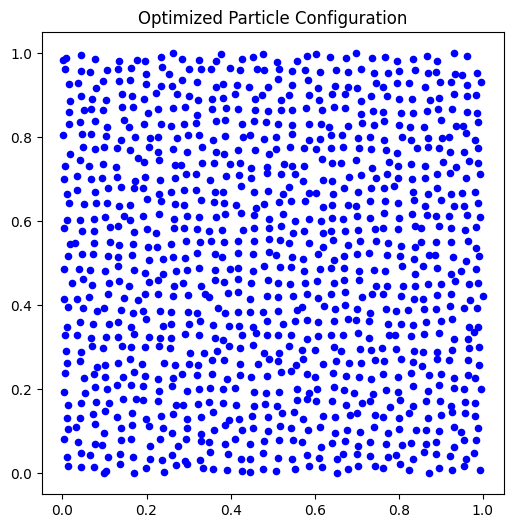

(1652,)


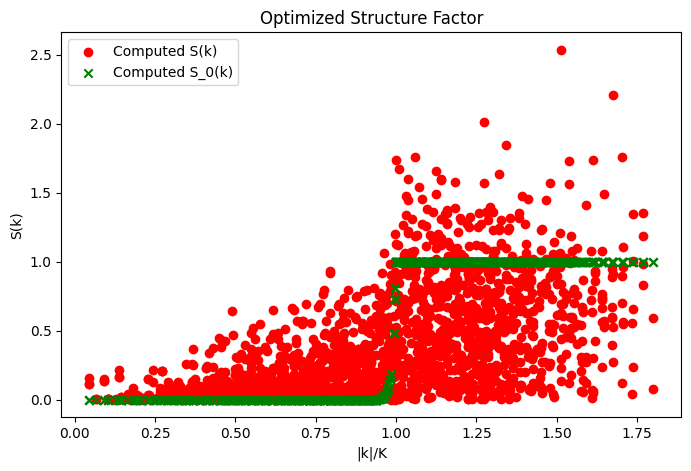

In [185]:
np.random.seed(0)  # For reproducibility

# ---== Parameters ==--- #

N = 1024

# Target structure factor parameters
H = 1e-4
alpha = 100.
K_cutoff = 44*np.pi
D = np.pow(K_cutoff, -alpha)

r_init = perturbed_point_pattern(N)
# since some point pattern generation algos dont give exactly N
N = r_init.shape[0] 

k = np.ascontiguousarray(generate_k_vectors(int(4 * np.sqrt(2*N/10))))
M = k.shape[1]

# Plot wave vectors used:
plot_wave_vectors(k)

# target structure factor precomputation
S0_k = compute_S0(k, D, H, alpha, K_cutoff)

# Plot before optimization
plot_particles(r_init, "Initial Particle Configuration")
plot_structure_factor(r_init, k, K_cutoff, S0_k, "Initial Structure Factor")

print("Value before optimizing: ", objective_function(r_init.flatten(), k, S0_k))

# ---== Run Optimization ==--- #
res = minimize(
    fun=objective_function,
    x0=r_init.flatten(),
    jac=gradient_function,
    args=(k, S0_k),
    method="BFGS",
    options={"disp": True, "maxiter": 1},
    tol=1e-8
)

# ---== Postprocess ==--- #

r_opt = res.x.reshape(N, 2)  # Final particle positions
print(res)

# Save point pattern:
outfile = f"point_patterns/pp.npy"
np.save(outfile, r_opt)
with open("point_patterns/parms.csv", 'w') as f:
        f.write("N, M, D, H, K_cutoff, alpha\n")
        f.write(f"{N},{M},{D},{H},{K_cutoff},{alpha}\n")
print("parameters saved to parms.csv")
print(f"phi saved to {outfile}")

# Plot after optimization
plot_particles(r_opt, "Optimized Particle Configuration")
plot_structure_factor(r_opt, k, K_cutoff, S0_k, "Optimized Structure Factor")

In [186]:
import time

Ns = []
Ms = []
o_ts = []
g_ts = []

for N_pow in range(4, 13):
    np.random.seed(0)
    
    N = 2**N_pow

    # Target structure factor parameters
    H = 1e-4
    alpha = 100.
    K_cutoff = 44*np.pi
    D = np.pow(K_cutoff, -alpha)

    r_init = np.ascontiguousarray(perturbed_point_pattern(N))
    # since some point pattern generation algos dont give exactly N
    N = r_init.shape[0] 

    k = np.ascontiguousarray(generate_k_vectors(int(4 * np.sqrt(2*N/10))))
    M = k.shape[1]

    # target structure factor precomputation
    S0_k = compute_S0(k, D, H, alpha, K_cutoff)
    # print(f"M = {M}, N = {N}")
    start = time.perf_counter()
    for i in range(100):
        temp = objective_function(r_init.flatten(), k, S0_k)
    end = time.perf_counter()
    o_ts.append(end-start)
    # print(f"time for 100 iterations of objecive function: {end - start}")

    start = time.perf_counter()
    for i in range(100):
        temp = gradient_function(r_init.flatten(), k, S0_k)
    end = time.perf_counter()
    g_ts.append(end-start)
    Ns.append(N)
    Ms.append(M)
    # print(f"time for 100 iterations of gradient function: {end - start}")

print(Ns)
print(Ms)
print(o_ts)
print(g_ts)

[16, 36, 64, 121, 256, 529, 1024, 2025, 4096]
[27, 49, 97, 189, 391, 860, 1652, 3199, 6497]
[0.36276290006935596, 0.25719489995390177, 0.3867658004164696, 0.25109799997881055, 0.29954580031335354, 0.3304006000980735, 0.365087500307709, 0.4850465999916196, 0.7148213000036776]
[1.2351199998520315, 0.9257253999821842, 1.0367527999915183, 0.8088998002931476, 0.8573079002089798, 0.9066086001694202, 0.9127306998707354, 1.218501899857074, 1.6219084998592734]


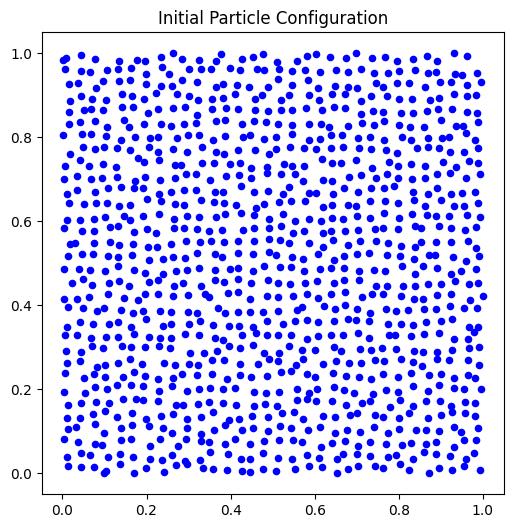

(1351,)


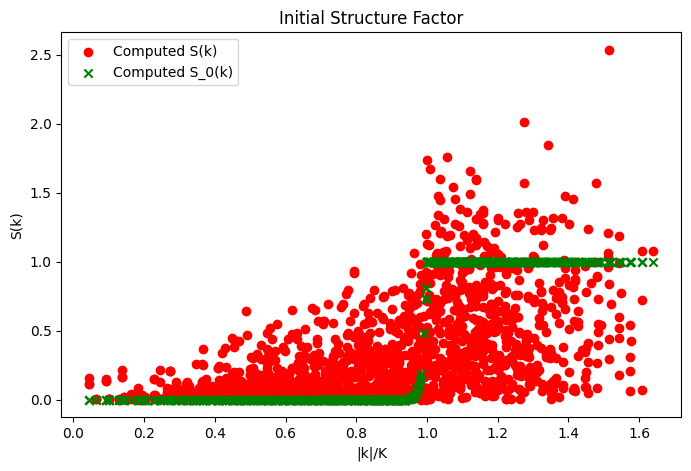

(non nuFFT) Value after optimizing:  1.7908030219903437


In [187]:
# Some testing for correctness

def compute_S(k, r):
    N = r.shape[0] 
    k_dot_r = r @ k  # (N, M)
    sum_exp = np.sum(np.exp(1j * k_dot_r), axis=0)  # (M,)
    return np.abs(sum_exp)**2 / N

def plot_structure_factor(r, k, K_cutoff, S0_k, title):
    S_kr = compute_S(k, r)
    print(S_kr.shape)
    k_magnitude = np.linalg.norm(k, axis=0)
    plt.figure(figsize=(8, 5))
    plt.scatter(k_magnitude/K_cutoff, S_kr, color="red", label="Computed S(k)")
    plt.scatter(k_magnitude/K_cutoff, S0_k, color="green", label="Computed S_0(k)", marker="x")
    plt.xlabel("|k|/K")
    plt.ylabel("S(k)")
    plt.title(title)
    plt.legend()
    plt.show()

k = np.ascontiguousarray(generate_k_vectors())
M = k.shape[1]

# Plot wave vectors used:
S0_k = compute_S0(k, D, H, alpha, K_cutoff)

plot_particles(r_opt, "Initial Particle Configuration")
plot_structure_factor(r_opt, -k, K_cutoff, S0_k, "Initial Structure Factor") # the strucutre factor should be the same for -k (=> it is)

print("(non nuFFT) Value after optimizing: ", objective_function(r_opt.flatten(), k, S0_k)) # here we use the non nuFFT way to check if it is also small (=> it is)